In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("data.csv")  #importing the dataset

In [5]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
corr_matrix = df.iloc[:,2:32].corr() #removing the first and last column and getting correlation

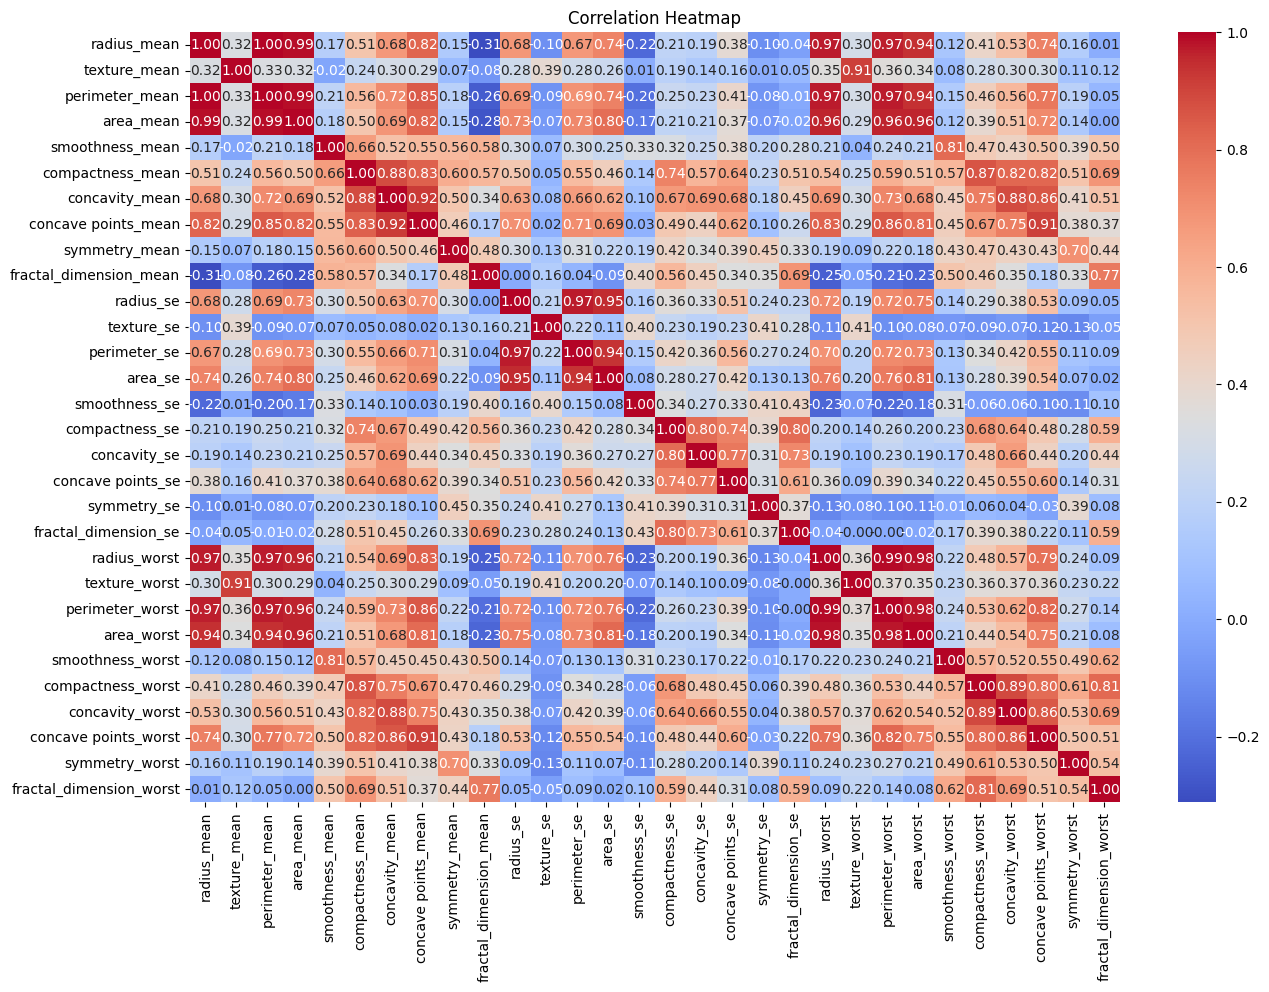

In [ ]:
plt.figure(figsize=(15, 10))  # Set figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")  # heatmap command
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
X = df[["radius_worst"]] # independent variable
Y = df["perimeter_worst"] # dependent variable

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(    # train test split
    X, Y, test_size=0.2, random_state=42 
)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),            # specifying the models
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():      
    model.fit(X_train, y_train)                 # fitting model
    y_pred = model.predict(X_test)              # making predictions 
    rmse = mean_squared_error(y_test, y_pred, squared=False)    # calulating rmse
    r2 = r2_score(y_test, y_pred)                               # calulating r2 score
    results[name] = {'RMSE': rmse, 'R²': r2}


C:\Users\abdul\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\abdul\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\abdul\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


                       RMSE        R²
Linear Regression  3.396426  0.990301
Decision Tree      5.291229  0.976461
Random Forest      4.388805  0.983806


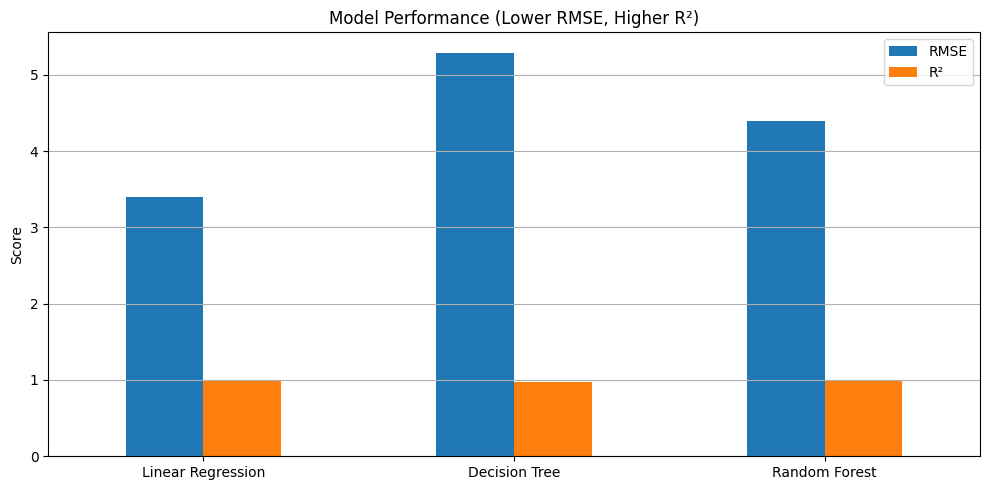

In [12]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Optional: Plot
results_df.plot(kind='bar', figsize=(10, 5), title='Model Performance (Lower RMSE, Higher R²)')
plt.xticks(rotation=0)
plt.ylabel('Score')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and target
X = df[["radius_worst"]]
Y = df["perimeter_worst"]

# Models dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

# 5-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each model
for name, model in models.items():
    mse_scores = []
    r2_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Append metrics
        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    print(f"Model: {name}")
    print(f"  MSE Scores: {np.round(mse_scores, 4)}")
    print(f"  Avg MSE: {np.mean(mse_scores):.4f}")
    print(f"  R² Scores: {np.round(r2_scores, 4)}")
    print(f"  Avg R²: {np.mean(r2_scores):.4f}\n")


Model: Linear Regression
  MSE Scores: [11.5357 16.4255 13.5132 18.1614 12.0422]
  Avg MSE: 14.3356
  R² Scores: [0.9903 0.9856 0.9892 0.9801 0.9894]
  Avg R²: 0.9869

Model: Decision Tree
  MSE Scores: [27.9971 29.8762 33.4616 29.0806 27.0705]
  Avg MSE: 29.4972
  R² Scores: [0.9765 0.9738 0.9732 0.9681 0.9762]
  Avg R²: 0.9735

Model: Random Forest
  MSE Scores: [19.0414 23.9837 25.4063 25.6765 23.0428]
  Avg MSE: 23.4301
  R² Scores: [0.984  0.9789 0.9796 0.9719 0.9797]
  Avg R²: 0.9788



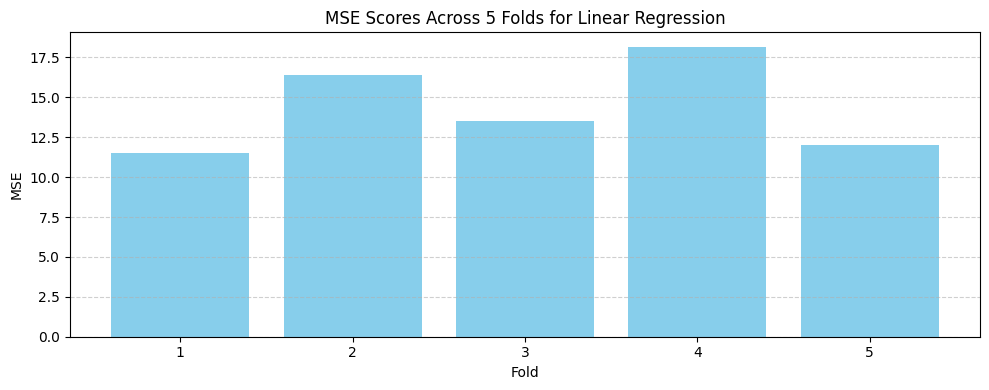

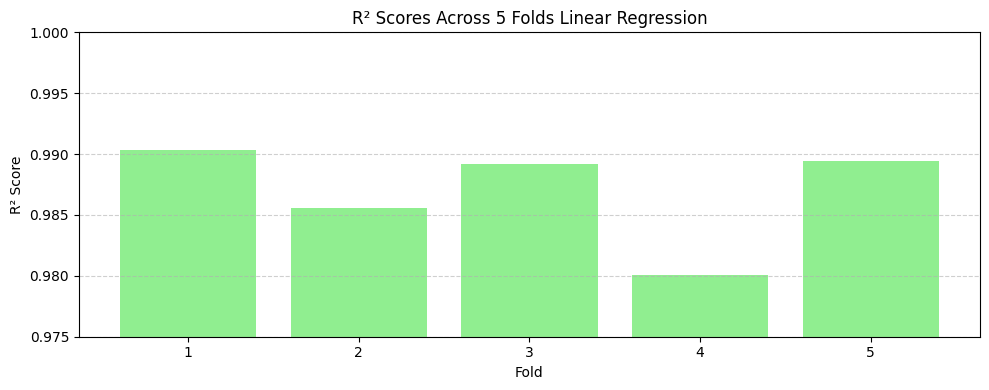

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Fold numbers
folds = [1, 2, 3, 4, 5]

# Provided scores
mse_scores = [11.5357, 16.4255, 13.5132, 18.1614, 12.0422]
r2_scores = [0.9903, 0.9856, 0.9892, 0.9801, 0.9894]

# Plot MSE scores
plt.figure(figsize=(10, 4))
plt.bar(folds, mse_scores, color='skyblue')
plt.title('MSE Scores Across 5 Folds for Linear Regression')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.xticks(folds)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot R² scores
plt.figure(figsize=(10, 4))
plt.bar(folds, r2_scores, color='lightgreen')
plt.title('R² Scores Across 5 Folds Linear Regression')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(folds)
plt.ylim(0.975, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


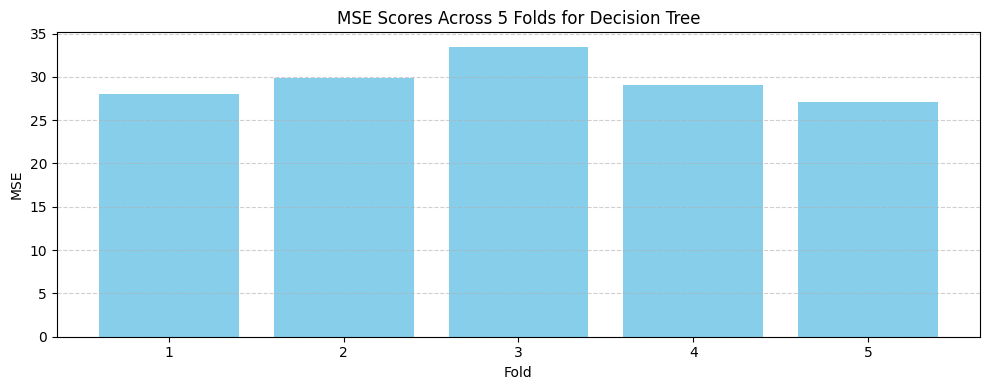

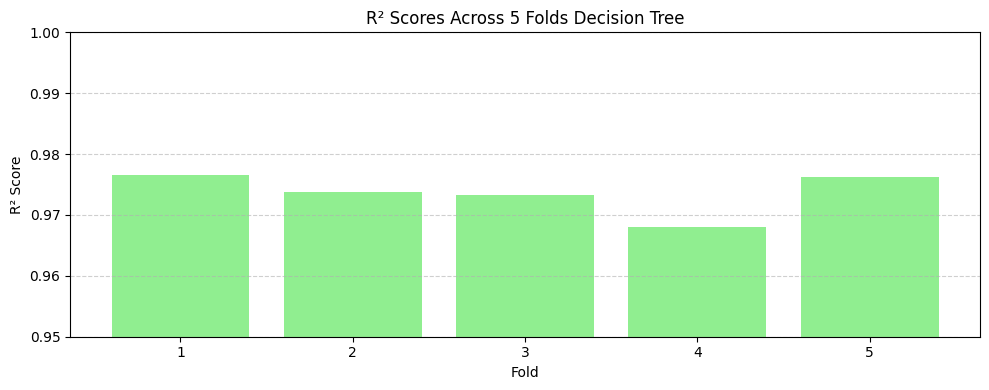

In [18]:
# Provided scores
mse_scores = [27.9971, 29.8762, 33.4616, 29.0806, 27.0705]
r2_scores = [0.9765, 0.9738, 0.9732, 0.9681, 0.9762]



plt.figure(figsize=(10, 4))
plt.bar(folds, mse_scores, color='skyblue')
plt.title('MSE Scores Across 5 Folds for Decision Tree')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.xticks(folds)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot R² scores
plt.figure(figsize=(10, 4))
plt.bar(folds, r2_scores, color='lightgreen')
plt.title('R² Scores Across 5 Folds Decision Tree')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(folds)
plt.ylim(0.95, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

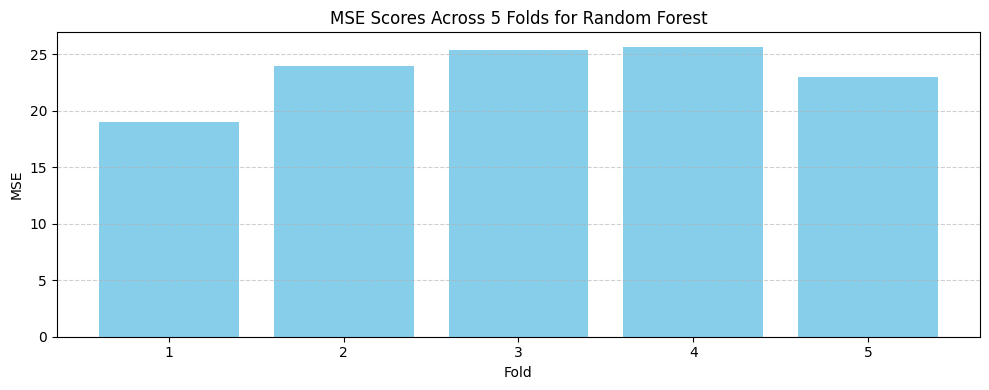

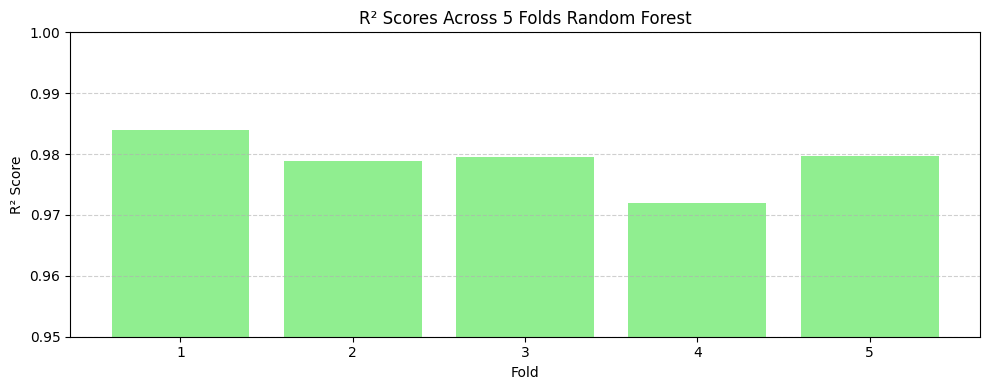

In [19]:
# Provided scores
mse_scores = [19.0414, 23.9837, 25.4063, 25.6765, 23.0428]
r2_scores = [0.984,  0.9789, 0.9796, 0.9719, 0.9797]



plt.figure(figsize=(10, 4))
plt.bar(folds, mse_scores, color='skyblue')
plt.title('MSE Scores Across 5 Folds for Random Forest')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.xticks(folds)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot R² scores
plt.figure(figsize=(10, 4))
plt.bar(folds, r2_scores, color='lightgreen')
plt.title('R² Scores Across 5 Folds Random Forest')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(folds)
plt.ylim(0.95, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()